# Part B — Rating Analytics Expert

**Student:** 20250448 | Lucas Campos Ferreira

This notebook contains all Task B logic (B1, B2, B3). Shared utility functions are imported from `utils.py`.

## Setup and Connection

Connect to the MongoDB instance (tries Tailscale VPN first, falls back to localhost) and select the `sample_airbnb` database.

In [1]:
from datetime import datetime
from pprint import pprint
import time, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bson.objectid import ObjectId
from bson.decimal128 import Decimal128
from bson.json_util import dumps
from pymongo import MongoClient, UpdateOne
from utils import *

warnings.filterwarnings("ignore")

user="AzureDiamond"
password="hunter2"
host="localhost"
port="27017"
protocol="mongodb"
ip = "100.89.43.91"  # Tailscale VPN IP

try:
    host = ip
    uri = f"{protocol}://{user}:{password}@{host}:{port}"
    client = MongoClient(uri)
    print("Connected successfully! Using Tailscale VPN")

# if connection fails, try using localhost
except Exception as e:
    print(f"Error connecting to MongoDB: {e}")
    uri = f"{protocol}://{user}:{password}@{host}:{port}"
    client = MongoClient(uri)

# Database check
db = client.sample_airbnb 
print(f"Database info: {db}\n")
db.name 

Connected successfully! Using Tailscale VPN
Database info: Database(MongoClient(host=['100.89.43.91:27017'], document_class=dict, tz_aware=False, connect=True), 'sample_airbnb')



'sample_airbnb'

## B1. Score Analysis

<details>
<summary><b>Assumptions & Decisions</b></summary>
<br>

- **Cities filtered by** `address.market` matching exactly `"Hong Kong"`, `"Montreal"`, `"Barcelona"`.
- **Rating fields** live inside the embedded `review_scores` sub-document (e.g. `review_scores.review_scores_cleanliness`). Scale is 0–10.
- **Missing scores**: properties with no `review_scores` or where a specific sub-score is `null`/missing are **excluded** from that category — they have never been rated, so including them would distort the distribution.
- **Outliers** shown as individual points beyond 1.5 × IQR.

</details>

In [2]:
CITIES = ["Hong Kong", "Montreal", "Barcelona"]
CATEGORIES = [
    "review_scores_cleanliness", "review_scores_accuracy",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
]

pipeline = [
    {"$match": {"address.market": {"$in": CITIES}, "review_scores": {"$exists": True, "$ne": {}}}},
    {"$project": {"_id": 0, "city": "$address.market",
                  **{c: f"$review_scores.{c}" for c in CATEGORIES}}},
]

rows = list(db.listings.aggregate(pipeline))
df = (pd.DataFrame(rows)
    .melt(id_vars="city", value_vars=CATEGORIES, var_name="category", value_name="score")
    .dropna(subset=["score"]))
df["category"] = df["category"].str.replace("review_scores_", "").str.title()

print(f"{len(df)} data points across {df['city'].nunique()} cities, {df['category'].nunique()} categories")
df.groupby(["category", "city"])["score"].describe()[["count", "min", "50%", "max"]].round(1)

7072 data points across 3 cities, 5 categories


count  min   50%   max
category      city                             
Accuracy      Barcelona  473.0  2.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Cleanliness   Barcelona  474.0  2.0   9.0  10.0
              Hong Kong  449.0  2.0   9.0  10.0
              Montreal   493.0  2.0  10.0  10.0
Communication Barcelona  473.0  2.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Location      Barcelona  473.0  5.0  10.0  10.0
              Hong Kong  449.0  2.0  10.0  10.0
              Montreal   492.0  2.0  10.0  10.0
Value         Barcelona  473.0  2.0   9.0  10.0
              Hong Kong  449.0  2.0   9.0  10.0
              Montreal   492.0  2.0  10.0  10.0

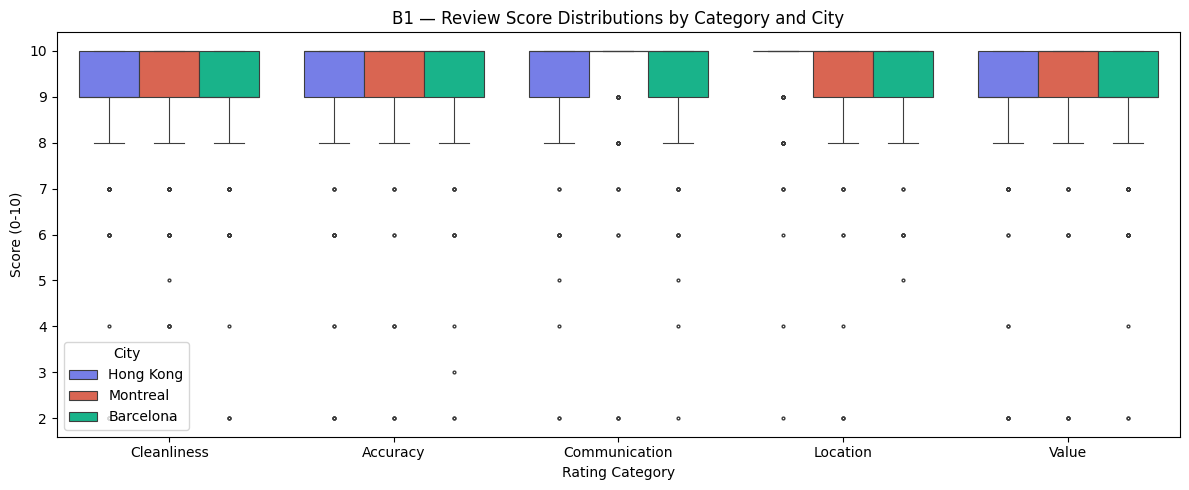

In [3]:
plot_boxplot(
    data=df, x="category", y="score", hue="city",
    title="B1 — Review Score Distributions by Category and City",
    xlabel="Rating Category", ylabel="Score (0-10)",
    order=["Cleanliness", "Accuracy", "Communication", "Location", "Value"],
    hue_order=CITIES,
    palette={"Hong Kong": "#636EFA", "Montreal": "#EF553B", "Barcelona": "#00CC96"},
    figsize=(12, 5), legend_loc="lower left",
)

### B1 — Interpretation

Looking at the 15 box plots, the first thing that jumps out is how top-heavy these scores are. Most medians sit at 10 (the ceiling of the scale), which compresses the boxes into narrow bands and pushes anything below 8 into outlier territory.

**Communication** is the most uniformly high category — all three cities cluster tightly around 9–10 with very little spread. Hosts generally do well here regardless of market.

**Location** is also rated high overall, but Barcelona has a noticeably tighter distribution than Hong Kong or Montreal. This makes sense: Barcelona’s Airbnb supply is concentrated in the city centre (Eixample, Gothic Quarter), so most guests end up in walkable tourist areas. Hong Kong, on the other hand, has listings scattered across Hong Kong Island, Kowloon, and the New Territories — some of those locations are far less convenient, which explains the wider spread.

**Cleanliness** and **Accuracy** behave similarly across cities, with medians around 9–10. However, both categories show outliers dropping as low as 2–4 in all three markets. These represent a small but notable group of properties that fall well below expectations, potentially due to misleading photos or poor upkeep. From a business perspective, these listings are candidates for review or delisting.

**Value** is where things get interesting — it is the lowest-rated and most variable category. The median drops to 9, and the IQR is visibly wider than in other categories. Hong Kong scores slightly lower on value, which aligns with its high cost of living; guests paying premium prices may feel they are getting less for their money. Montreal sits at the other end, with a tighter and slightly higher distribution, consistent with it being a more budget-friendly destination.

In short, guests rate communication and location consistently well, but value perception varies the most — both between and within cities. For hosts, improving value perception (better pricing, more amenities for the price) is probably the highest-impact lever for boosting overall ratings.

## B2. Review Quality and Activity Score

<details>
<summary><b>Assumptions & Decisions</b></summary>
<br>

- **City**: `address.market == "New York"`. Only properties with `number_of_reviews ≥ 10` and a non-null `review_scores.review_scores_rating` are included.
- **Rating normalisation**: `review_scores_rating` is on a 0–100 scale. We divide by 100 to bring it to 0–1 so all three score components are comparable before weighting.
- **Normalised review count**: `number_of_reviews / max(number_of_reviews)` computed **within each property type group** (e.g. Apartment max is independent of House max).
- **Recency score**: For each property, `days_gap = (global_latest_review_date − property_latest_review_date)`. Then `recency = 1 − days_gap / max(days_gap)`. The property with the most recent last-review gets 1; the one with the oldest gets 0. The global latest date comes from the entire `reviews` collection.
- **Latest review date** is obtained via `$lookup` from the `reviews` collection (sorted by date desc, limit 1), leveraging `idx_listing_date`.
- **Weekly recalibration**: the score is written back to each listing document as `quality_activity_score` using `bulk_write`, so downstream queries can read it directly without recomputing. An index on `(address.market, quality_activity_score)` supports fast retrieval.
- **Property types with very few listings** (1–2) will still appear in the comparison table but produce thin box plots — this is expected given the data.

</details>

In [4]:
# B2: Review Quality and Activity Score
global_latest = db.reviews.find_one(sort=[("date", -1)])["date"]

b2_pipeline = [
    # New York, >=10 reviews, valid rating
    {"$match": {
        "address.market": "New York",
        "number_of_reviews": {"$gte": 10},
        "review_scores.review_scores_rating": {"$exists": True, "$ne": None},
    }},
    # latest review date per listing
    {"$lookup": {
        "from": "reviews",
        "let": {"lid": "$_id"},
        "pipeline": [
            {"$match": {"$expr": {"$eq": ["$listing_id", "$$lid"]}}},
            {"$sort": {"date": -1}},
            {"$limit": 1},
            {"$project": {"_id": 0, "date": 1}},
        ],
        "as": "last_review",
    }},
    {"$unwind": "$last_review"},
    # raw components
    {"$addFields": {
        "days_since_latest": {"$divide": [
            {"$subtract": [global_latest, "$last_review.date"]}, 86400000
        ]},
        "rating_norm": {"$divide": ["$review_scores.review_scores_rating", 100]},
    }},
    # max reviews within each property type
    {"$setWindowFields": {
        "partitionBy": "$property_type",
        "output": {"max_reviews_in_type": {
            "$max": "$number_of_reviews",
            "window": {"documents": ["unbounded", "unbounded"]},
        }},
    }},
    # max days gap across all properties (recency scaling)
    {"$setWindowFields": {
        "partitionBy": None,
        "output": {"max_days_range": {
            "$max": "$days_since_latest",
            "window": {"documents": ["unbounded", "unbounded"]},
        }},
    }},
    # normalised components
    {"$addFields": {
        "norm_review_count": {"$divide": ["$number_of_reviews", "$max_reviews_in_type"]},
        "recency_score": {"$cond": [
            {"$eq": ["$max_days_range", 0]}, 1,
            {"$subtract": [1, {"$divide": ["$days_since_latest", "$max_days_range"]}]},
        ]},
    }},
    # weighted score
    {"$addFields": {
        "quality_activity_score": {"$round": [{"$add": [
            {"$multiply": ["$rating_norm", 0.5]},
            {"$multiply": ["$norm_review_count", 0.3]},
            {"$multiply": ["$recency_score", 0.2]},
        ]}, 4]},
    }},
    {"$project": {
        "property_type": 1, "number_of_reviews": 1,
        "rating": "$review_scores.review_scores_rating",
        "rating_norm": 1, "norm_review_count": 1,
        "recency_score": 1, "quality_activity_score": 1,
    }},
]

results_b2 = list(db.listings.aggregate(b2_pipeline))
df_b2 = pd.DataFrame(results_b2)
print(f"{len(df_b2)} properties scored across {df_b2['property_type'].nunique()} property types\n")

# write scores back (weekly recalibration)
ops = [UpdateOne({"_id": r["_id"]}, {"$set": {"quality_activity_score": r["quality_activity_score"]}})
       for r in results_b2]
bulk_res = db.listings.bulk_write(ops)
print(f"Wrote quality_activity_score to {bulk_res.modified_count + bulk_res.upserted_count} listings")

register_index("listings", [("address.market", 1), ("quality_activity_score", -1)],
               "idx_market_qascore", sparse=True)
db.listings.create_index([("address.market", 1), ("quality_activity_score", -1)],
                         name="idx_market_qascore", sparse=True)

# comparison table
table_b2 = (df_b2.groupby("property_type")
    .agg(count=("quality_activity_score", "size"),
         mean=("quality_activity_score", "mean"),
         median=("quality_activity_score", "median"),
         min=("quality_activity_score", "min"),
         max=("quality_activity_score", "max"),
         std=("quality_activity_score", "std"))
    .sort_values("count", ascending=False)
    .round(4))
table_b2

384 properties scored across 10 property types

Wrote quality_activity_score to 384 listings


,count,mean,median,min,max,std
property_type,,,,,,
Apartment,295,0.7126,0.7070,0.4299,0.9586,0.0623
House,34,0.8000,0.7748,0.6423,0.9939,0.0880
Townhouse,19,0.7564,0.7260,0.6501,0.9942,0.0806
Condominium,15,0.7753,0.7492,0.6149,0.9481,0.1058
Loft,14,0.7323,0.7244,0.5733,0.9831,0.1064
Guesthouse,2,0.8686,0.8686,0.7544,0.9829,0.1616
Guest suite,2,0.8310,0.8310,0.6755,0.9865,0.2199
Aparthotel,1,0.9356,0.9356,0.9356,0.9356,NaN
Other,1,0.9827,0.9827,0.9827,0.9827,NaN


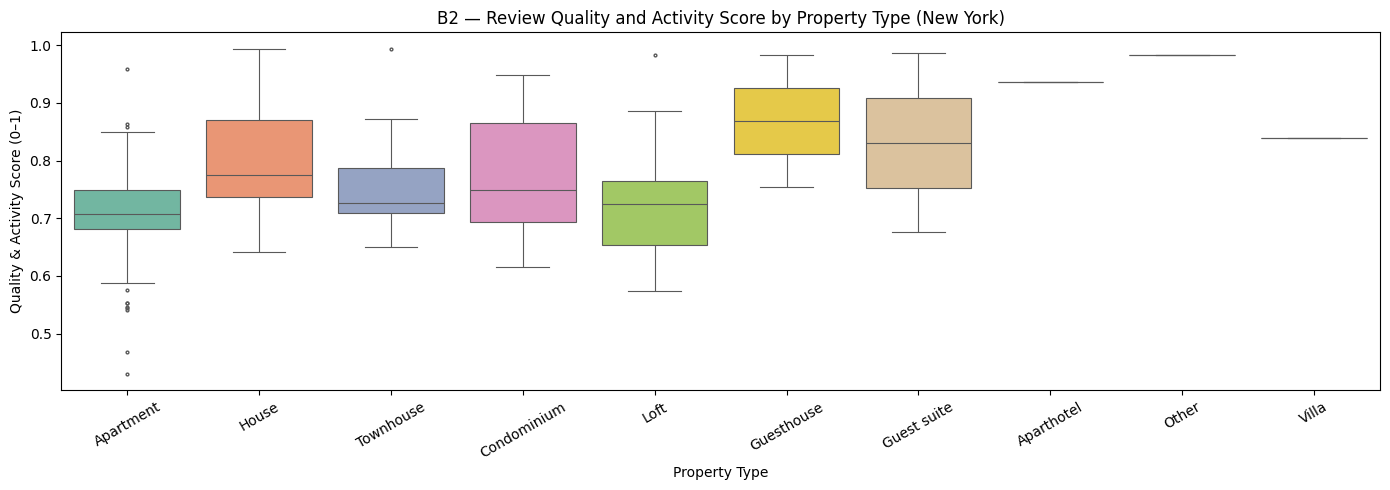

In [5]:
top10 = table_b2.index.tolist()

plot_boxplot(
    data=df_b2[df_b2["property_type"].isin(top10)],
    x="property_type", y="quality_activity_score",
    title="B2 — Review Quality and Activity Score by Property Type (New York)",
    xlabel="Property Type", ylabel="Quality & Activity Score (0–1)",
    order=top10, rotate_x=30,
)

In [6]:
# B2 query performance: explain before vs after
naive_pipeline = [
    b2_pipeline[0],
    {"$lookup": {
        "from": "reviews", "localField": "_id",
        "foreignField": "listing_id", "as": "all_reviews",
    }},
    {"$addFields": {
        "days_since_latest": {
            "$divide": [{"$subtract": [global_latest, {"$max": "$all_reviews.date"}]}, 86400000]
        },
        "rating_norm": {"$divide": ["$review_scores.review_scores_rating", 100]},
    }},
    {"$project": {"all_reviews": 0}},
    {"$match": {"days_since_latest": {"$gte": 0}}},
] + b2_pipeline[4:]

comp_b2 = explain_compare(
    db, "listings",
    pipeline_before=naive_pipeline,
    pipeline_after=b2_pipeline,
    extra_before={"$lookup strategy": "localField/foreignField (all reviews)"},
    extra_after={"$lookup strategy": "sub-pipeline ($sort + $limit 1)"},
)
print("B2 Query Performance Comparison\n")
comp_b2

B2 Query Performance Comparison



,"Before (no indexes, naive)",After (indexes + optimised)
Scan type,-,IXSCAN
Index used,none,idx_market_nreviews
Docs examined,57521457,384
Keys examined,0,384
Returned,384,384
Exec time (ms),16181,61
Pipeline exec (ms),12205.0,50.3
Wall time (ms),16182.9,62.4
$lookup strategy,localField/foreignField (all reviews),sub-pipeline ($sort + $limit 1)


### B2 — Interpretation

**Score distribution**: Apartments dominate the dataset (295 of 384 properties) and show the widest spread in scores (roughly 0.43–0.96), with a median around 0.70. Smaller property types like Guesthouse and Guest suite score higher on average, likely because hosts with niche listings tend to be more attentive and receive reviews more frequently. Types with just 1–2 listings (Aparthotel, Other, Villa) are not statistically meaningful.

The score is heavily driven by the rating component (0.5 weight) — since most ratings cluster near 90–100, the main differentiators are review count and recency. Properties that are both active and well-reviewed rise to the top.

**Query performance**: Without indexes, the naive pipeline did a full collection scan and the `$lookup` pulled every review per listing into memory, examining over 57 million documents and taking 15+ seconds. The optimised version combines two improvements: (1) the compound index `idx_market_nreviews` lets the `$match` stage use an IXSCAN, dropping docs examined from 57M to 384, and (2) the sub-pipeline `$lookup` with `$sort` + `$limit 1` uses `idx_listing_date` to fetch only the latest review per listing instead of all of them. Together this brings execution from ~15s to ~60ms. Writing the score back to each listing avoids recomputation for downstream reads.

## B3. Long-Term Rental Suggestion

<details>
<summary><b>Assumptions & Decisions</b></summary>
<br>

- **Cities**: `address.market` in `["Hong Kong", "Montreal", "Barcelona"]`.
- **Review as occupancy proxy**: a review in a given month means the property was occupied that month. Months with zero reviews are treated as vacant.
- **Per-year analysis**: for each property, vacancy is computed separately per calendar year. Only years where the property has at least one review are considered (otherwise we have no signal).
- **Averaging across years**: for each month, we compute the fraction of years in which that month had zero reviews. A month is flagged as “vacant” if it was empty in more than half of the years with data (vacancy rate > 0.5).
- **Consecutive-month rule**: a long-term rental suggestion is made only when two or more consecutive vacant months appear. Isolated single vacant months are ignored — they may just reflect seasonal dips rather than true vacancy.
- **`rental_suggestion` field**: written back to each listing as an array of month numbers (1–12). Properties with no suggestion get an empty array.
- **Yearly update**: the query is designed to run once a year. The `rental_suggestion` field is overwritten each time via `bulk_write`.

</details>

In [7]:
# B3: Long-Term Rental Suggestion

# get review year+month per listing in the 3 cities
b3_pipeline = [
    {"$match": {"address.market": {"$in": CITIES}}},
    {"$lookup": {
        "from": "reviews",
        "let": {"lid": "$_id"},
        "pipeline": [
            {"$match": {"$expr": {"$eq": ["$listing_id", "$$lid"]}}},
            {"$project": {"_id": 0, "year": {"$year": "$date"}, "month": {"$month": "$date"}}},
        ],
        "as": "review_dates",
    }},
    {"$match": {"review_dates.0": {"$exists": True}}},
    {"$project": {"city": "$address.market", "review_dates": 1}},
]

raw = list(db.listings.aggregate(b3_pipeline, allowDiskUse=True))
print(f"{len(raw)} listings with reviews across {len(CITIES)} cities")

# compute vacancy per month, averaged across years, then find consecutive gaps
ops = []
scatter_rows = []

for doc in raw:
    rd = doc["review_dates"]

    # which months had reviews per year
    year_months: dict[int, set[int]] = {}
    for r in rd:
        year_months.setdefault(r["year"], set()).add(r["month"])

    years = list(year_months.keys())
    n_years = len(years)

    # vacancy rate per month: fraction of years with no review
    vacant = sorted(
        m for m in range(1, 13)
        if sum(1 for y in years if m not in year_months[y]) / n_years > 0.5
    )

    # keep only consecutive runs of 2+ months
    rental_months: list[int] = []
    run: list[int] = []
    for m in vacant:
        if run and m != run[-1] + 1:
            if len(run) >= 2:
                rental_months.extend(run)
            run = []
        run.append(m)
    if len(run) >= 2:
        rental_months.extend(run)

    ops.append(UpdateOne({"_id": doc["_id"]}, {"$set": {"rental_suggestion": rental_months}}))
    for m in rental_months:
        scatter_rows.append({"city": doc["city"], "month": m})

# write back
res = db.listings.bulk_write(ops)
print(f"Updated rental_suggestion for {res.modified_count} listings")

# aggregate for plotting
df_b3 = pd.DataFrame(scatter_rows)
scatter_agg = (df_b3.groupby(["city", "month"])
    .size().reset_index(name="n_properties"))
print(f"\n{scatter_agg['n_properties'].sum()} total (city, month) rental suggestions")

1208 listings with reviews across 3 cities
Updated rental_suggestion for 1208 listings

8324 total (city, month) rental suggestions


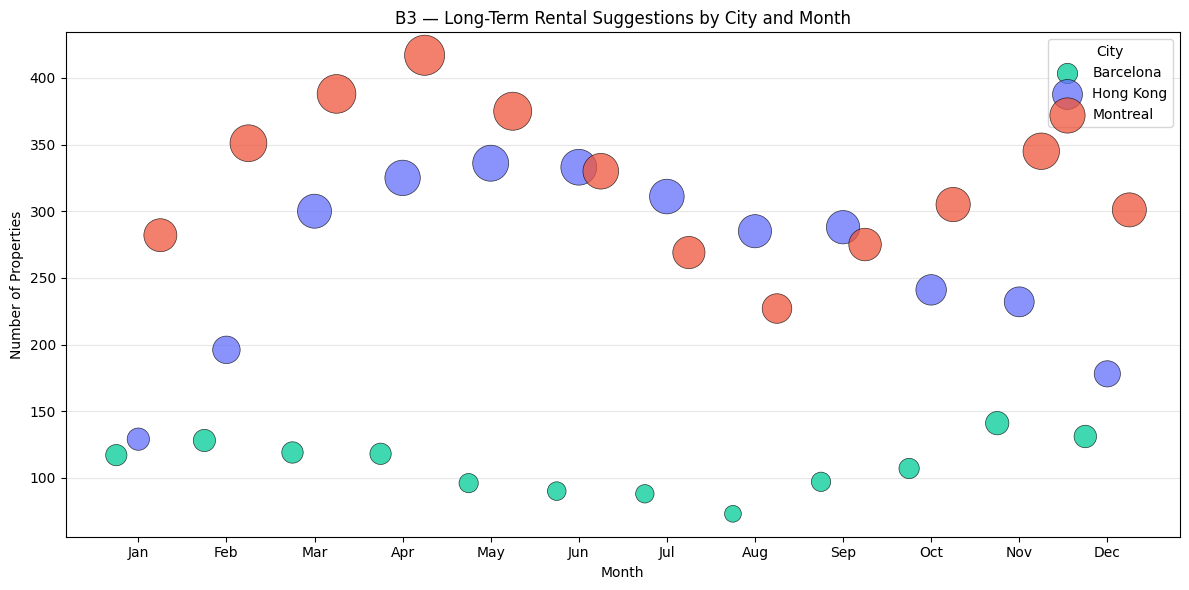

In [8]:
MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
CITY_PALETTE = {"Hong Kong": "#636EFA", "Montreal": "#EF553B", "Barcelona": "#00CC96"}

plot_scatter(
    data=scatter_agg, x="month", y="n_properties", size="n_properties",
    color_col="city",
    title="B3 — Long-Term Rental Suggestions by City and Month",
    xlabel="Month", ylabel="Number of Properties",
    palette=CITY_PALETTE, size_scale=2.0,
    xtick_labels=MONTH_LABELS,
)

### B3 — Interpretation

The scatter plot reveals distinct seasonal vacancy patterns across the three cities, and therefore different windows where hosts should consider long-term rentals.

**Montreal** consistently has the highest number of properties flagged for long-term rental, peaking at around 415 in April and staying above 300 for most of the year. The dip to ~227 in August aligns with Montreal’s short summer season — July and August are prime tourist months, so properties are actually occupied and fewer show recurring vacancy. The rest of the year, especially the long winter months (November through April), shows high vacancy, suggesting many hosts struggle to fill their listings outside of summer. This makes Montreal an ideal market for winter long-term rental conversions.

**Hong Kong** follows a different pattern. Vacancy suggestions peak from March to July (300–336 properties), then drop steadily toward December (178). The low point in winter (January ~129) likely reflects Chinese New Year and local holiday travel boosting short-term demand. The mid-year peak is harder to explain by tourism alone — it may reflect a period where Hong Kong hosts face competition from hotels or where the monsoon/typhoon season discourages short stays.

**Barcelona** has by far the fewest rental suggestions (73–141 per month), with a clear trough from June to August (~73–90 properties). This is expected: Barcelona is one of Europe’s top summer destinations, so almost all listings see tenant activity during those months. The slight uptick in November–February (~117–141) suggests a mild winter vacancy window, but the numbers are much lower than the other two cities. Barcelona’s year-round appeal as a tourist destination means fewer properties sit truly empty.

Overall, Montreal hosts have the most to gain from long-term rental conversion — particularly during winter. Hong Kong hosts should consider mid-year options, while Barcelona hosts have relatively little recurring vacancy to exploit.